In [7]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/sourav2083/class-dataset-movies/movie_prediction_dataset_final.csv')
df

,release_year,budget,runtime,is_sequel,director_name,director_popularity,lead_actor1,lead_actor1_popularity,primary_genre,genre2,studio_1,studio_2,brand_name,mpaa_rating,release_month,is_holiday_release,Distributor,First_Week_Income
0,2009,40000000,111,0,Mira Nair,1.3916,Hilary Swank,2.2810,Adventure,Drama,AE Electra Productions,Fox Searchlight Pictures,General,PG,10,0,Fox Searchlight Pictures,5305832.0
1,2009,237000000,162,1,James Cameron,4.3403,Sam Worthington,4.0107,Action,Adventure,Dune Entertainment,Lightstorm Entertainment,Avatar,PG-13,12,1,Twentieth Century Fox,137094051.0
2,2009,60000000,100,0,Henry Selick,1.6349,Dakota Fanning,7.9341,Animation,Family,LAIKA,Pandemonium,General,PG,2,0,Focus Features,20235921.0
3,2009,175000000,96,0,Pete Docter,1.3480,Ed Asner,1.4701,Animation,Comedy,Pixar,NaN,General,PG,5,0,Walt Disney Studios Motion Pictures,93072435.0
4,2009,70000000,153,0,Quentin Tarantino,3.8346,Brad Pitt,9.0310,Drama,Thriller,Universal Pictures,The Weinstein Company,General,R,8,0,The Weinstein Company,53703427.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3585,2025,23800000,93,0,Alex Parkinson,0.0618,Woody Harrelson,6.0845,Thriller,Drama,Dark Castle Entertainment,MetFilm Production,General,PG-13,2,0,Focus Features,10456885.0
3586,2025,9000000,107,0,Tony Tost,0.1493,Sydney Sweeney,21.2483,Crime,Thriller,Bron Studios,Creative Wealth Media Finance,General,R,8,0,NaN,NaN
3587,2025,8500000,118,0,Jon Avnet,0.3870,Neal McDonough,4.5676,Drama,NaN,Angel Studios,Unity Productions Foundation,General,PG,5,0,Angel,8607185.0
3588,2025,13000000,105,0,Johnny Martin,0.3193,Josh Duhamel,2.9623,Action,Thriller,Buffalo 8,Iervolino & Lady Bacardi Entertainment,General,R,6,0,NaN,NaN


In [8]:
df = df.dropna()

In [9]:
X = df.drop(columns=['First_Week_Income', 'director_name', 'lead_actor1', 'studio_1', 'studio_2', 'brand_name', 'Distributor', 'genre2'])
X

,release_year,budget,runtime,is_sequel,director_popularity,lead_actor1_popularity,primary_genre,mpaa_rating,release_month,is_holiday_release
0,2009,40000000,111,0,1.3916,2.2810,Adventure,PG,10,0
1,2009,237000000,162,1,4.3403,4.0107,Action,PG-13,12,1
2,2009,60000000,100,0,1.6349,7.9341,Animation,PG,2,0
4,2009,70000000,153,0,3.8346,9.0310,Drama,R,8,0
5,2009,40000000,108,0,0.6359,7.9497,Comedy,PG-13,6,0
...,...,...,...,...,...,...,...,...,...,...
3580,2025,12000000,88,0,0.7757,1.1327,Drama,PG-13,3,0
3582,2025,10000000,104,0,0.2375,2.0294,Horror,R,3,0
3584,2025,2500000,92,0,0.3594,6.9117,Romance,R,1,0
3585,2025,23800000,93,0,0.0618,6.0845,Thriller,PG-13,2,0


In [10]:
y = df['First_Week_Income']
y

0         5305832.0
1       137094051.0
2        20235921.0
4        53703427.0
5        50595503.0
           ...     
3580     12166985.0
3582      1521347.0
3584       324009.0
3585     10456885.0
3589      4073964.0
Name: First_Week_Income, Length: 1765, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
print(X_train.shape)

(1412, 10)


In [13]:
print(X_test.shape)

(353, 10)


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['budget', 'runtime', 'director_popularity', 'lead_actor1_popularity', 'release_year', 'release_month', 'is_sequel', 'is_holiday_release']
cat_cols = ['primary_genre', 'mpaa_rating']

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100))
    ]
    
)

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['budget', 'runtime',
                                                   'director_popularity',
                                                   'lead_actor1_popularity',
                                                   'release_year',
                                                   'release_month', 'is_sequel',
                                                   'is_holiday_release']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['primary_genre',
                                                   'mpaa_rating'])])),
                ('regressor', RandomForestRegressor())])

In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {rmse}")

RMSE: 26350549.709806453


In [21]:
comparison_df = pd.DataFrame({'Actual Income': y_test, 'Predicted Income': y_pred})

print(comparison_df.head())

      Actual Income  Predicted Income
676         26187.0        6159976.95
3040     13465649.0        8879390.82
74       25584474.0       26186787.65
2479     23284580.0       21793303.51
231        543216.0       17995899.42


In [22]:
comparison_df

,Actual Income,Predicted Income
676,26187.0,6159976.95
3040,13465649.0,8879390.82
74,25584474.0,26186787.65
2479,23284580.0,21793303.51
231,543216.0,17995899.42
...,...,...
3292,225520.0,5341624.80
335,9708949.0,11787840.41
3102,971512.0,16289680.55
2870,37543570.0,8006883.20


In [27]:
y_test_samples = y_test.iloc[:25]
y_pred_samples = y_pred[:25]

/tmp/ipykernel_58/422690889.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


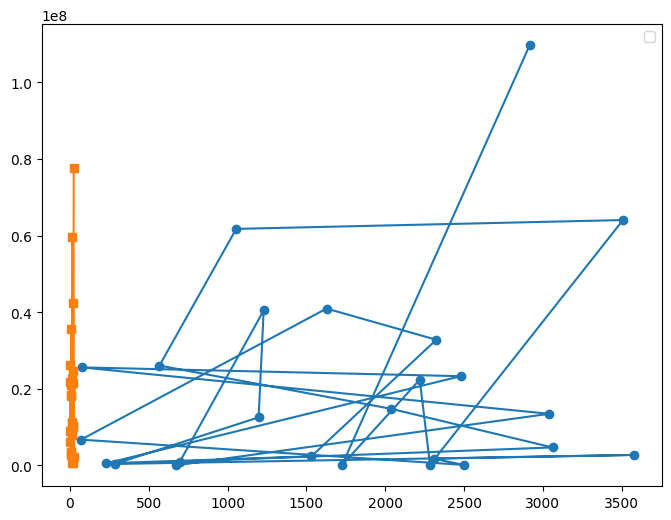

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(y_test_samples, marker='o')
plt.plot(y_pred_samples, marker='s')
plt.legend()

plt.show()



In [29]:
import joblib

joblib.dump(model_pipeline, 'Movie_income_model.pkl')

['Movie_income_model.pkl']

In [30]:
loaded_model = joblib.load('Movie_income_model.pkl')

new_predictions = loaded_model.predict(X_test)

In [31]:
new_predictions

array([6.15997695e+06, 8.87939082e+06, 2.61867876e+07, 2.17933035e+07,
       1.79958994e+07, 3.51094785e+06, 1.84853240e+07, 2.09431354e+07,
       3.56636725e+07, 3.25899520e+06, 2.78947322e+06, 8.02968331e+06,
       6.09235990e+05, 2.26996469e+07, 5.95038918e+07, 1.08909935e+07,
       1.12293132e+07, 1.02408176e+07, 9.95252821e+06, 2.14573595e+07,
       4.24125200e+07, 7.49424010e+05, 2.45246516e+07, 2.22623318e+06,
       7.76109660e+07, 2.86532846e+07, 6.88719410e+06, 5.59301557e+07,
       4.60339888e+06, 2.14727087e+07, 1.47006814e+07, 4.82284878e+06,
       5.03564544e+06, 2.42935827e+06, 1.51787177e+07, 2.17909232e+06,
       1.67532847e+07, 3.92621290e+07, 1.85676621e+07, 3.09055148e+07,
       6.82626868e+06, 1.00022884e+07, 2.21166362e+06, 6.93298233e+07,
       1.23834871e+07, 1.95458394e+07, 2.42893866e+07, 2.13088975e+07,
       6.70031160e+06, 3.46397081e+07, 1.07426649e+07, 1.45188521e+06,
       1.33045552e+08, 2.07969985e+07, 1.54248810e+08, 1.14474550e+07,
      